# K-Medoids Clustering on the Sphere (Haversine Distance)

This notebook demonstrates **K-Medoids** (PAM algorithm) as an alternative to K-Means for clustering points on a sphere.

## K-Means vs K-Medoids

**Analogy:** Imagine you're choosing team captains on a playground.
- **K-Means** creates an imaginary "average kid" who might not actually exist — then assigns everyone to the nearest phantom captain. On a sphere, this phantom floats *inside* the sphere, so we had to invent spherical means to project it back onto the surface.
- **K-Medoids** picks an *actual kid* from the group as captain — the one who minimizes total distance to their teammates. No projection tricks needed. Just a distance function.

### Why K-Medoids Matters

| | K-Means | K-Medoids |
|---|---------|----------|
| **Center** | Virtual mean (must be computed) | Actual data point (selected) |
| **Requires** | Distance + mean formula | Distance only |
| **Outlier robustness** | Sensitive (mean gets pulled) | Robust (medoid stays put) |
| **Complexity** | O(nk) per iteration | O(n²k) per iteration |
| **Works on any metric?** | Needs custom centroid | Yes — plug in any distance |

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

np.random.seed(42)
R = 1.0  # unit sphere

print("Setup complete!")

Setup complete!


## 2. Spherical Utilities & Data Generation

Same data generation as the spherical K-means notebook — 300 pre-clustered points on a unit sphere.

In [2]:
def haversine(lat1, lon1, lat2, lon2, r=1.0):
    """Great-circle distance on a sphere via Haversine formula."""
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    a = np.clip(a, 0, 1)
    return 2 * r * np.arcsin(np.sqrt(a))


def latlon_to_cartesian(lat, lon, r=1.0):
    """Convert lat/lon (radians) to 3D Cartesian."""
    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)
    z = r * np.sin(lat)
    return x, y, z


def cartesian_to_latlon(x, y, z):
    """Convert 3D Cartesian to lat/lon (radians)."""
    lat = np.arcsin(np.clip(z / np.sqrt(x**2 + y**2 + z**2 + 1e-16), -1, 1))
    lon = np.arctan2(y, x)
    return lat, lon


def spherical_mean(lats, lons):
    """Spherical mean via Cartesian averaging + re-projection."""
    x, y, z = latlon_to_cartesian(lats, lons)
    mx, my, mz = np.mean(x), np.mean(y), np.mean(z)
    norm = np.sqrt(mx**2 + my**2 + mz**2)
    if norm < 1e-10:
        return lats[0], lons[0]
    return cartesian_to_latlon(mx/norm, my/norm, mz/norm)


def generate_clustered_points_on_sphere(n_points=300, n_clusters=5, spread_deg=15, seed=42):
    """Generate pre-clustered points on a unit sphere."""
    rng = np.random.default_rng(seed)
    spread_rad = np.deg2rad(spread_deg)
    
    center_lats_deg = np.array([60, -40, 10, -60, 35])
    center_lons_deg = np.array([30, -60, 150, 80, -130])
    center_lats = np.deg2rad(center_lats_deg[:n_clusters])
    center_lons = np.deg2rad(center_lons_deg[:n_clusters])
    
    points_per = n_points // n_clusters
    all_lats, all_lons, all_labels = [], [], []
    
    for i in range(n_clusters):
        n = points_per if i < n_clusters - 1 else n_points - points_per * (n_clusters - 1)
        dlat = rng.normal(0, spread_rad, size=n)
        dlon = rng.normal(0, spread_rad / np.cos(center_lats[i] + 1e-8), size=n)
        lats = np.clip(center_lats[i] + dlat, -np.pi/2, np.pi/2)
        lons = (center_lons[i] + dlon + np.pi) % (2 * np.pi) - np.pi
        all_lats.append(lats)
        all_lons.append(lons)
        all_labels.append(np.full(n, i))
    
    return (np.concatenate(all_lats), np.concatenate(all_lons),
            np.concatenate(all_labels), center_lats, center_lons)


# Generate data
K = 5
lats, lons, true_labels, seed_lats, seed_lons = generate_clustered_points_on_sphere(
    n_points=300, n_clusters=K, spread_deg=15
)

print(f"Generated {len(lats)} points in {K} clusters")

Generated 300 points in 5 clusters


## 3. Precompute Full Distance Matrix

K-Medoids operates on a **pairwise distance matrix** — the full $N \times N$ matrix of Haversine distances between every pair of points. This is the key difference: K-means only needs point-to-centroid distances, but K-Medoids needs all-pairs.

In [3]:
def compute_full_distance_matrix(lats, lons, r=1.0):
    """Compute N×N Haversine distance matrix."""
    n = len(lats)
    D = np.zeros((n, n))
    for i in range(n):
        D[i, :] = haversine(lats[i], lons[i], lats, lons, r)
    return D


D = compute_full_distance_matrix(lats, lons, r=R)

print(f"Distance matrix shape: {D.shape}")
print(f"Min nonzero distance: {D[D > 0].min():.4f} rad ({np.rad2deg(D[D > 0].min()):.2f}°)")
print(f"Max distance:         {D.max():.4f} rad ({np.rad2deg(D.max()):.2f}°)")
print(f"Mean distance:        {D.mean():.4f} rad ({np.rad2deg(D.mean()):.2f}°)")

Distance matrix shape: (300, 300)
Min nonzero distance: 0.0000 rad (0.00°)
Max distance:         3.1416 rad (180.00°)
Mean distance:        1.5369 rad (88.06°)


## 4. K-Medoids (PAM) Algorithm

**PAM = Partitioning Around Medoids.** Two phases:

1. **BUILD:** Initialize by greedily selecting medoids that minimize total distance
2. **SWAP:** For each (medoid, non-medoid) pair, check if swapping them reduces total cost. Repeat until no improving swap exists.

The beauty: we only ever look up entries in the precomputed distance matrix. No centroid math at all.

In [4]:
def kmedoids_pam(D, k=5, max_iter=100, seed=123):
    """
    K-Medoids clustering using the PAM algorithm.
    
    Parameters:
        D        : (N, N) precomputed distance matrix
        k        : number of clusters
        max_iter : maximum SWAP iterations
        seed     : random seed for initial BUILD step
    
    Returns:
        labels   : cluster assignment for each point
        medoids  : indices of medoid points
        history  : total cost per iteration
    """
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    
    # ── BUILD phase: greedy medoid initialization ──
    # First medoid: point that minimizes total distance to all others
    medoids = [np.argmin(D.sum(axis=1))]
    
    for _ in range(1, k):
        # For each non-medoid, compute its distance to nearest existing medoid
        dist_to_nearest = D[:, medoids].min(axis=1)
        # Next medoid: the point that reduces total distance the most
        candidates = [i for i in range(n) if i not in medoids]
        best_gain = -np.inf
        best_candidate = candidates[0]
        for c in candidates:
            # Gain: how much total distance decreases if we add c as a medoid
            gain = np.sum(np.maximum(dist_to_nearest - D[:, c], 0))
            if gain > best_gain:
                best_gain = gain
                best_candidate = c
        medoids.append(best_candidate)
    
    medoids = np.array(medoids)
    
    # Assign and compute initial cost
    dist_to_medoids = D[:, medoids]
    labels = np.argmin(dist_to_medoids, axis=1)
    total_cost = sum(dist_to_medoids[i, labels[i]] for i in range(n))
    history = [total_cost]
    
    print(f"BUILD phase complete. Initial cost: {total_cost:.4f}")
    
    # ── SWAP phase: iteratively improve ──
    for iteration in range(max_iter):
        best_swap = None
        best_delta = 0  # must be negative to improve
        
        non_medoids = [i for i in range(n) if i not in medoids]
        
        for m_idx in range(k):  # which medoid to swap out
            for h in non_medoids:  # which non-medoid to swap in
                # Compute cost change if medoids[m_idx] is replaced by h
                new_medoids = medoids.copy()
                new_medoids[m_idx] = h
                
                new_dist_to_medoids = D[:, new_medoids]
                new_labels = np.argmin(new_dist_to_medoids, axis=1)
                new_cost = sum(new_dist_to_medoids[i, new_labels[i]] for i in range(n))
                
                delta = new_cost - total_cost
                if delta < best_delta:
                    best_delta = delta
                    best_swap = (m_idx, h)
        
        if best_swap is None:
            print(f"SWAP phase converged at iteration {iteration + 1} (no improving swap)")
            break
        
        # Perform the best swap
        m_idx, h = best_swap
        old_medoid = medoids[m_idx]
        medoids[m_idx] = h
        
        dist_to_medoids = D[:, medoids]
        labels = np.argmin(dist_to_medoids, axis=1)
        total_cost = sum(dist_to_medoids[i, labels[i]] for i in range(n))
        history.append(total_cost)
    else:
        print(f"Reached max iterations ({max_iter})")
    
    return labels, medoids, history


# Run K-Medoids
med_labels, med_indices, med_history = kmedoids_pam(D, k=K, max_iter=50)

print(f"\nCluster sizes: {[np.sum(med_labels == i) for i in range(K)]}")
print(f"Medoid indices: {med_indices}")
print(f"Medoid positions (lat, lon):")
for i, idx in enumerate(med_indices):
    print(f"  Cluster {i+1}: ({np.rad2deg(lats[idx]):.1f}°, {np.rad2deg(lons[idx]):.1f}°)  [point #{idx}]")

BUILD phase complete. Initial cost: 109.9132
SWAP phase converged at iteration 5 (no improving swap)

Cluster sizes: [np.int64(61), np.int64(60), np.int64(60), np.int64(59), np.int64(60)]
Medoid indices: [175  85  45 244 238]
Medoid positions (lat, lon):
  Cluster 1: (12.6°, 153.5°)  [point #175]
  Cluster 2: (-46.2°, -61.0°)  [point #85]
  Cluster 3: (63.3°, 23.8°)  [point #45]
  Cluster 4: (34.1°, -134.6°)  [point #244]
  Cluster 5: (-61.0°, 80.2°)  [point #238]


## 5. K-Means (for comparison)

Run the same spherical K-means from our earlier notebook so we can compare.

In [5]:
def haversine_distance_matrix_to_centers(lats, lons, c_lats, c_lons, r=1.0):
    """Distance from all points to all centers."""
    n = len(lats)
    k = len(c_lats)
    dist = np.zeros((n, k))
    for j in range(k):
        dist[:, j] = haversine(lats, lons, c_lats[j], c_lons[j], r)
    return dist


def spherical_kmeans(lats, lons, k=5, max_iter=100, tol=1e-6, seed=123):
    """Spherical K-Means using Haversine + spherical mean centroids."""
    rng = np.random.default_rng(seed)
    n = len(lats)
    
    idx = rng.choice(n, size=k, replace=False)
    c_lats, c_lons = lats[idx].copy(), lons[idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        dist = haversine_distance_matrix_to_centers(lats, lons, c_lats, c_lons, R)
        labels = np.argmin(dist, axis=1)
        total = sum(dist[i, labels[i]] for i in range(n))
        history.append(total)
        
        new_c_lats, new_c_lons = np.zeros(k), np.zeros(k)
        for j in range(k):
            members = labels == j
            if np.sum(members) == 0:
                ri = rng.choice(n)
                new_c_lats[j], new_c_lons[j] = lats[ri], lons[ri]
            else:
                new_c_lats[j], new_c_lons[j] = spherical_mean(lats[members], lons[members])
        
        shift = haversine(c_lats, c_lons, new_c_lats, new_c_lons, R)
        c_lats, c_lons = new_c_lats, new_c_lons
        
        if np.max(shift) < tol:
            print(f"Spherical K-Means converged at iteration {iteration + 1}")
            break
    
    return labels, c_lats, c_lons, history


km_labels, km_c_lats, km_c_lons, km_history = spherical_kmeans(lats, lons, k=K)
print(f"Cluster sizes: {[np.sum(km_labels == i) for i in range(K)]}")

Spherical K-Means converged at iteration 4
Cluster sizes: [np.int64(54), np.int64(63), np.int64(7), np.int64(61), np.int64(115)]


## 6. Visualization

### 6a. K-Medoids vs K-Means — 3D Sphere

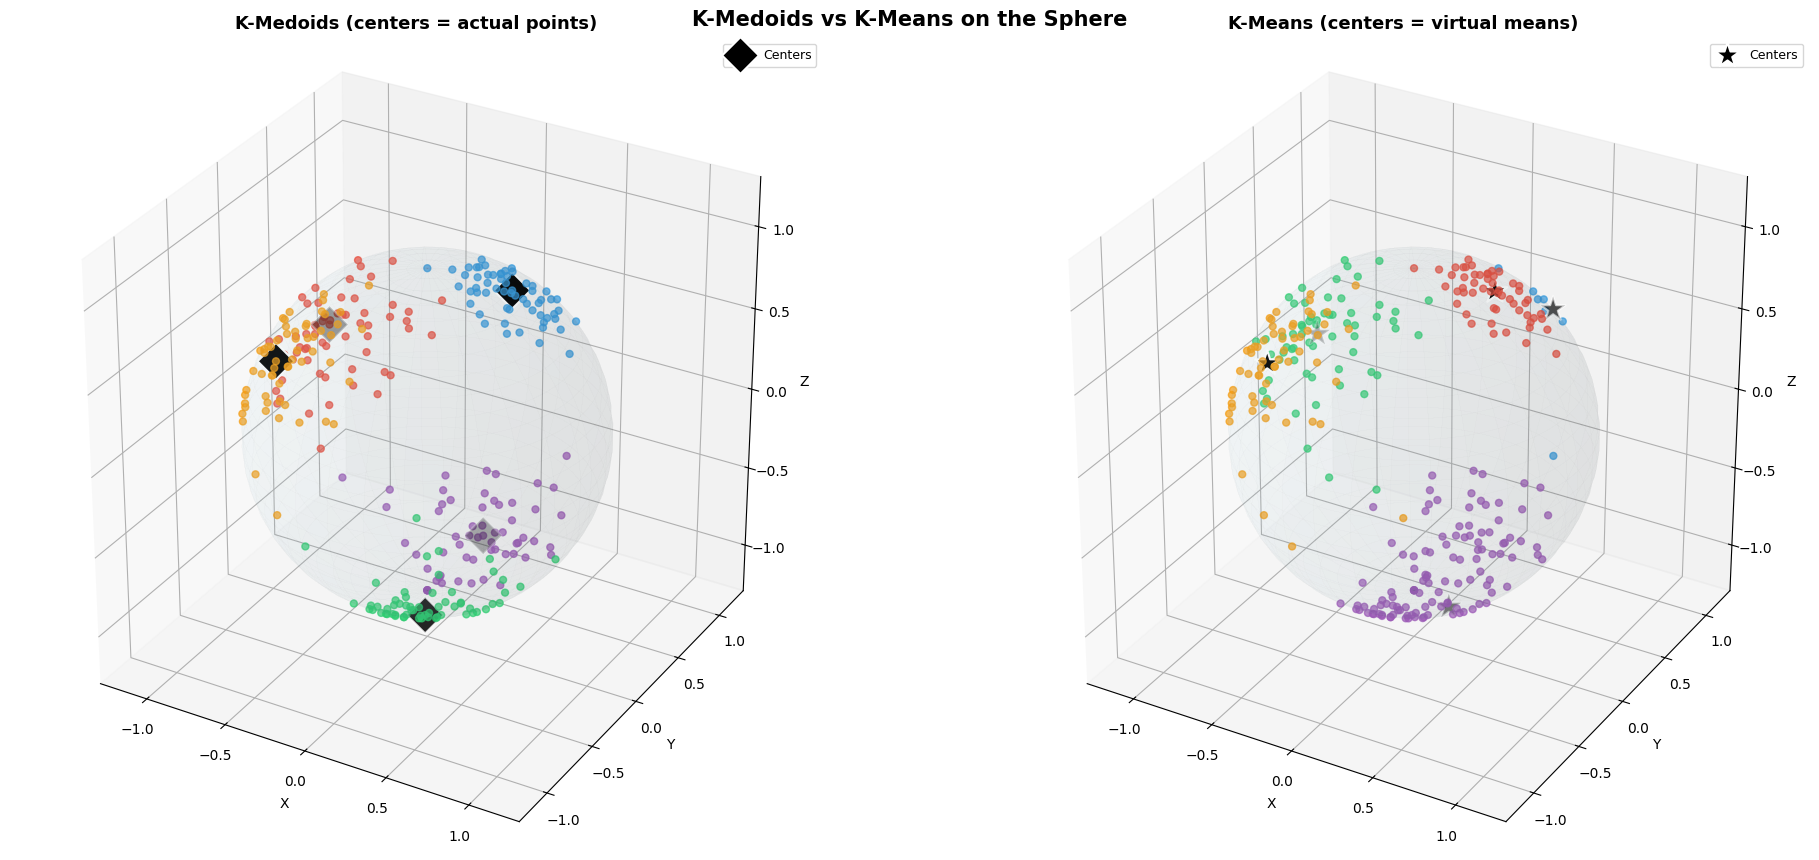

In [6]:
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

# Cartesian coords for plotting
px, py, pz = latlon_to_cartesian(lats, lons)

# K-Medoids centers (actual data points)
med_cx = px[med_indices]
med_cy = py[med_indices]
med_cz = pz[med_indices]

# K-Means centers (virtual)
km_cx, km_cy, km_cz = latlon_to_cartesian(km_c_lats, km_c_lons)

# Sphere wireframe
phi_grid = np.linspace(0, 2 * np.pi, 60)
theta_grid = np.linspace(-np.pi/2, np.pi/2, 30)
phi_m, theta_m = np.meshgrid(phi_grid, theta_grid)
xs = R * np.cos(theta_m) * np.cos(phi_m)
ys = R * np.cos(theta_m) * np.sin(phi_m)
zs = R * np.sin(theta_m)

fig, axes = plt.subplots(1, 2, figsize=(20, 9), subplot_kw={'projection': '3d'})

configs = [
    ('K-Medoids (centers = actual points)', med_labels, med_cx, med_cy, med_cz, 'D'),
    ('K-Means (centers = virtual means)', km_labels, km_cx, km_cy, km_cz, '*'),
]

for ax, (title, lbls, ccx, ccy, ccz, marker) in zip(axes, configs):
    ax.plot_surface(xs, ys, zs, alpha=0.05, color='lightblue', edgecolor='gray', linewidth=0.1)
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(px[mask], py[mask], pz[mask],
                   c=cluster_colors[i], s=25, alpha=0.7, depthshade=True)
    
    ax.scatter(ccx, ccy, ccz, c='black', marker=marker, s=350,
               edgecolors='white', linewidths=1.5, zorder=10, label='Centers')
    
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3]); ax.set_zlim([-1.3, 1.3])
    ax.set_box_aspect([1, 1, 1])
    ax.legend(fontsize=9)

plt.suptitle('K-Medoids vs K-Means on the Sphere',
             fontsize=15, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

### 6b. 2D Map Projection — Side by Side

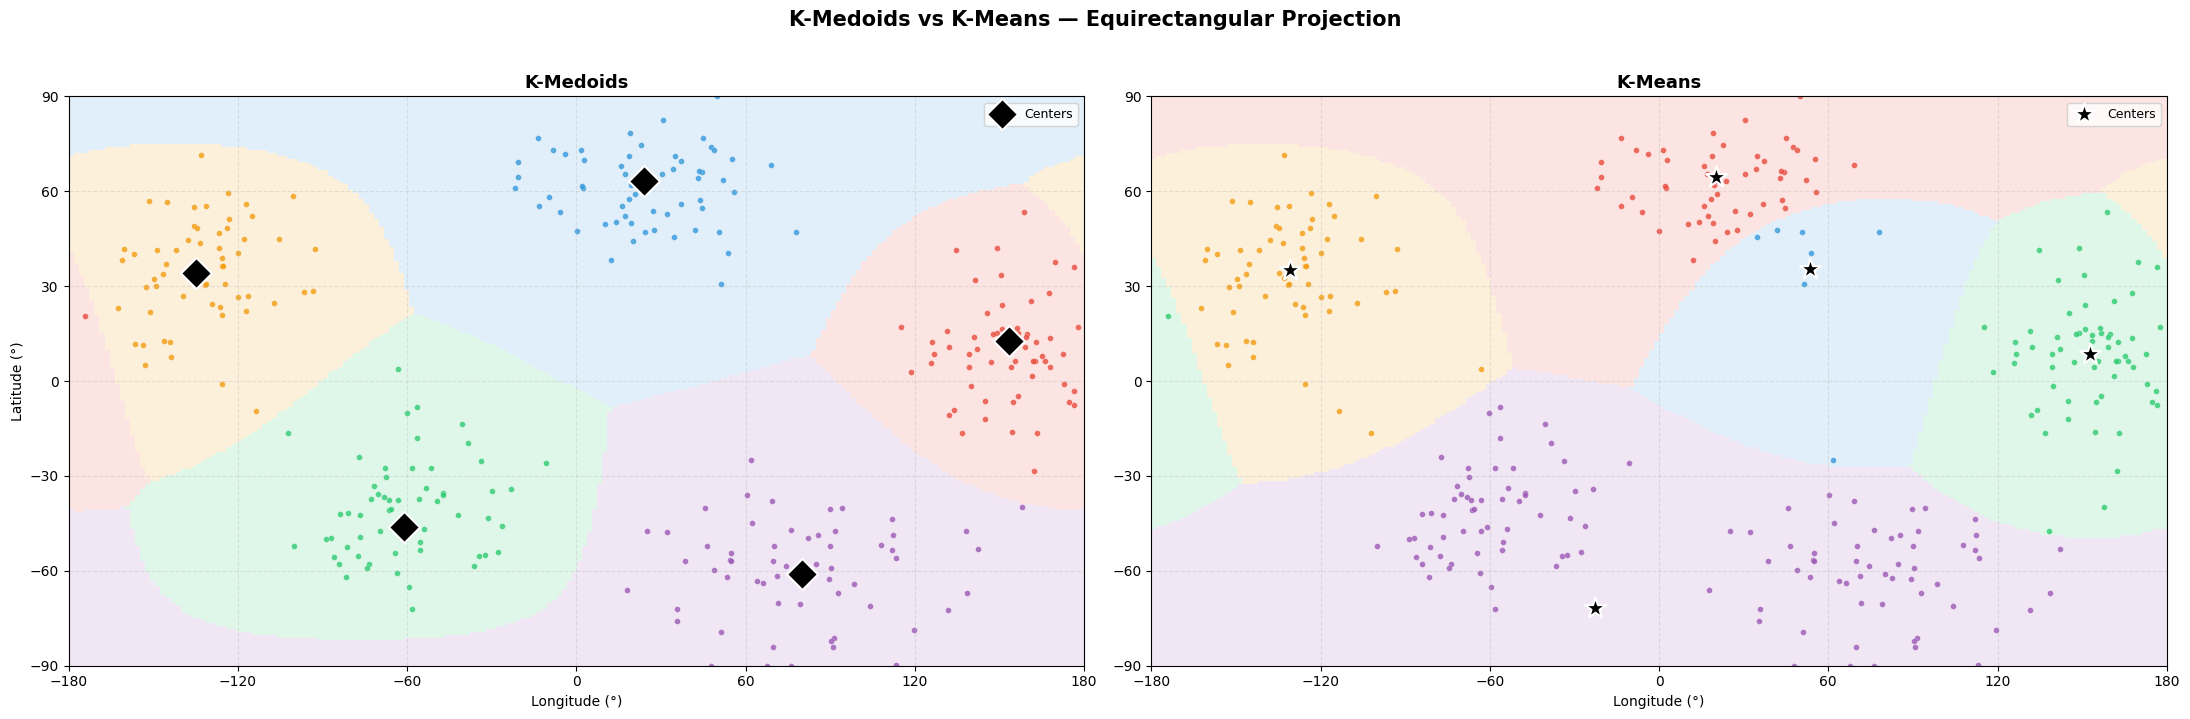

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Grid for Voronoi background
grid_res = 200
grid_lon = np.linspace(-np.pi, np.pi, grid_res)
grid_lat = np.linspace(-np.pi/2, np.pi/2, grid_res)
grid_lon_mesh, grid_lat_mesh = np.meshgrid(grid_lon, grid_lat)
grid_lats_flat = grid_lat_mesh.ravel()
grid_lons_flat = grid_lon_mesh.ravel()

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])

map_configs = [
    ('K-Medoids', med_labels, lats[med_indices], lons[med_indices], 'D'),
    ('K-Means', km_labels, km_c_lats, km_c_lons, '*'),
]

for idx, (name, lbls, c_la, c_lo, marker) in enumerate(map_configs):
    ax = axes[idx]
    
    # Territory shading
    g_d = haversine_distance_matrix_to_centers(grid_lats_flat, grid_lons_flat, c_la, c_lo, R)
    g_l = np.argmin(g_d, axis=1).reshape(grid_res, grid_res)
    ax.imshow(g_l, extent=[-180, 180, -90, 90], origin='lower', aspect='auto',
              cmap=cmap_bg, interpolation='nearest')
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(np.rad2deg(lons[mask]), np.rad2deg(lats[mask]),
                   c=cluster_colors[i], s=18, alpha=0.8, edgecolors='white', linewidths=0.2)
    
    ax.scatter(np.rad2deg(c_lo), np.rad2deg(c_la),
               c='black', marker=marker, s=250, edgecolors='white',
               linewidths=1.5, zorder=10, label='Centers')
    
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-90, 91, 30))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    if idx == 0:
        ax.set_ylabel('Latitude (°)')
    ax.legend(fontsize=9)

plt.suptitle('K-Medoids vs K-Means — Equirectangular Projection',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6c. Convergence Comparison

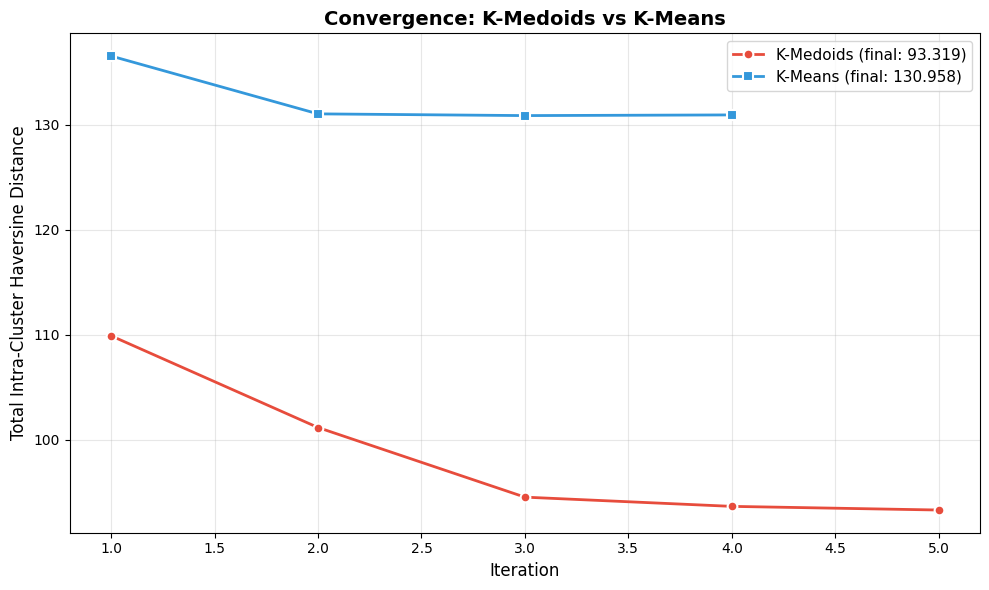

K-Medoids final cost: 93.3188
K-Means   final cost: 130.9583
Difference: 37.6395

💡 K-Means can achieve slightly lower cost because its centroids are free
   to sit anywhere on the sphere. K-Medoids is constrained to actual data points.


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(1, len(med_history)+1), med_history, 'o-', color='#e74c3c',
        markersize=7, linewidth=2, markerfacecolor='#e74c3c', markeredgecolor='white',
        markeredgewidth=1.5, label=f'K-Medoids (final: {med_history[-1]:.3f})')

ax.plot(range(1, len(km_history)+1), km_history, 's-', color='#3498db',
        markersize=7, linewidth=2, markerfacecolor='#3498db', markeredgecolor='white',
        markeredgewidth=1.5, label=f'K-Means (final: {km_history[-1]:.3f})')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Total Intra-Cluster Haversine Distance', fontsize=12)
ax.set_title('Convergence: K-Medoids vs K-Means', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"K-Medoids final cost: {med_history[-1]:.4f}")
print(f"K-Means   final cost: {km_history[-1]:.4f}")
print(f"Difference: {abs(med_history[-1] - km_history[-1]):.4f}")
print(f"\n💡 K-Means can achieve slightly lower cost because its centroids are free")
print(f"   to sit anywhere on the sphere. K-Medoids is constrained to actual data points.")

---
## 7. Outlier Robustness Test

This is where K-Medoids really shines. We inject outlier points far from any cluster and watch how each method reacts.

**K-Means** computes a mean — outliers pull the centroid toward them.
**K-Medoids** picks a real point — outliers are just weird members, the medoid stays put.

In [9]:
# Add 15 outlier points scattered randomly across the sphere
rng_out = np.random.default_rng(99)
n_outliers = 15
outlier_lats = rng_out.uniform(-np.pi/2, np.pi/2, n_outliers)
outlier_lons = rng_out.uniform(-np.pi, np.pi, n_outliers)

# Combine
lats_out = np.concatenate([lats, outlier_lats])
lons_out = np.concatenate([lons, outlier_lons])
outlier_mask = np.zeros(len(lats_out), dtype=bool)
outlier_mask[len(lats):] = True

print(f"Original: {len(lats)} points + {n_outliers} outliers = {len(lats_out)} total")

# Run K-Medoids on contaminated data
D_out = compute_full_distance_matrix(lats_out, lons_out, r=R)
med_out_labels, med_out_indices, med_out_hist = kmedoids_pam(D_out, k=K, max_iter=50)

# Run K-Means on contaminated data
km_out_labels, km_out_c_lats, km_out_c_lons, km_out_hist = spherical_kmeans(
    lats_out, lons_out, k=K
)

Original: 300 points + 15 outliers = 315 total
BUILD phase complete. Initial cost: 119.8424
SWAP phase converged at iteration 5 (no improving swap)
Spherical K-Means converged at iteration 7


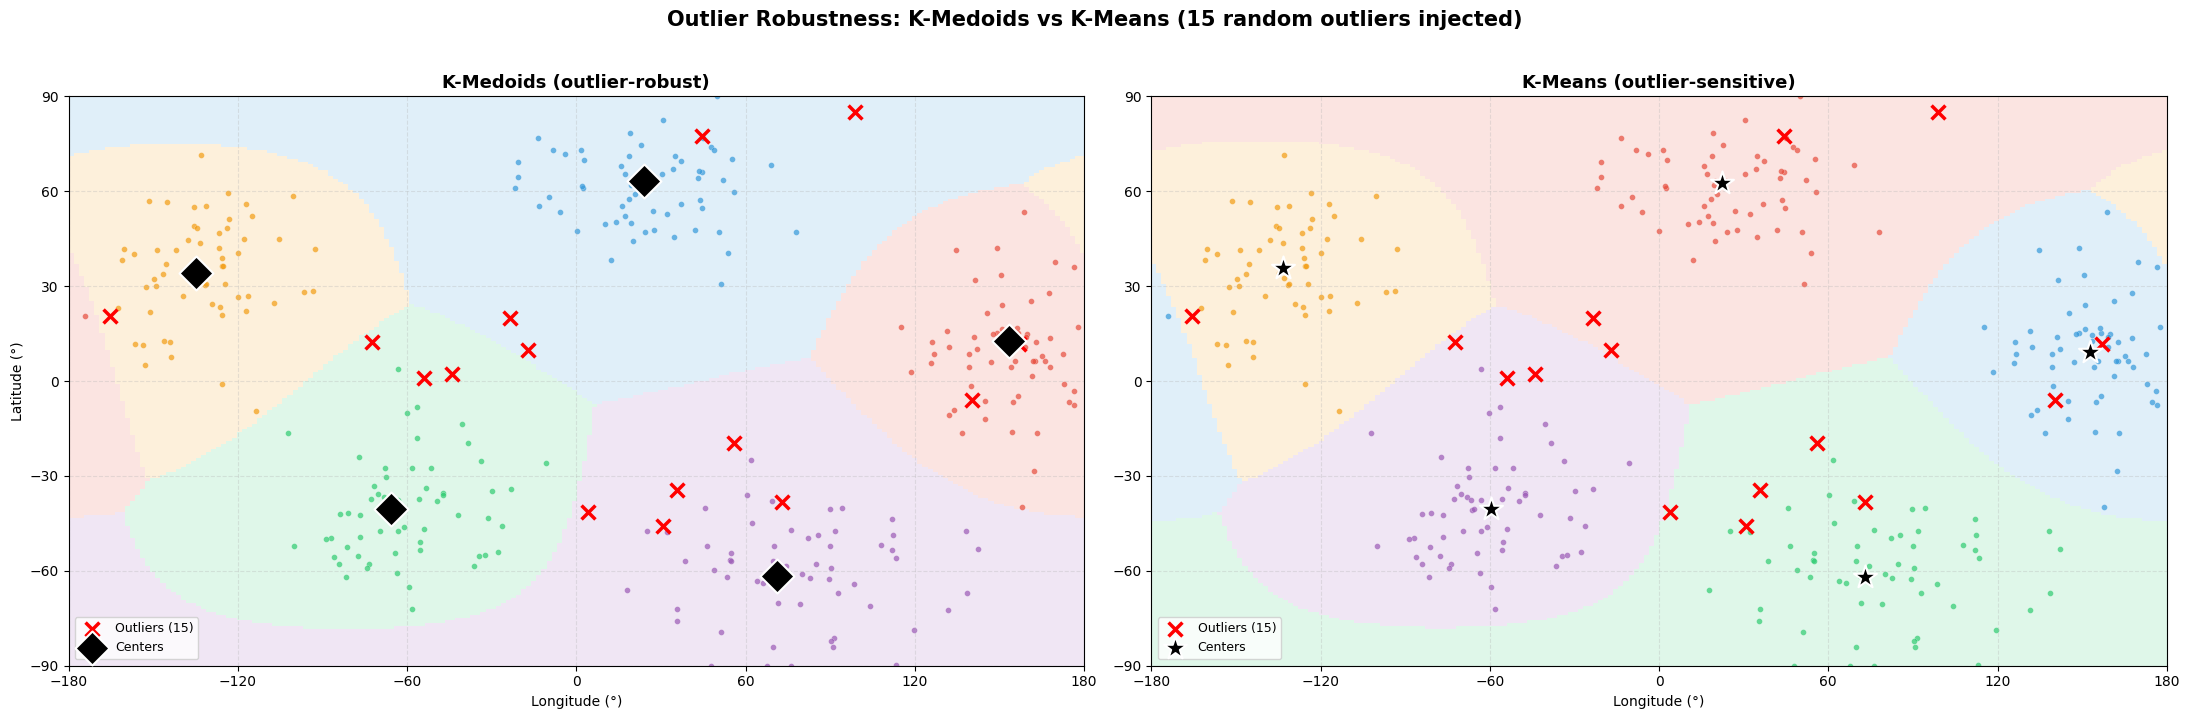

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

out_configs = [
    ('K-Medoids (outlier-robust)', med_out_labels,
     lats_out[med_out_indices], lons_out[med_out_indices], 'D'),
    ('K-Means (outlier-sensitive)', km_out_labels,
     km_out_c_lats, km_out_c_lons, '*'),
]

for idx, (name, lbls, c_la, c_lo, marker) in enumerate(out_configs):
    ax = axes[idx]
    
    # Territory shading
    g_d = haversine_distance_matrix_to_centers(grid_lats_flat, grid_lons_flat, c_la, c_lo, R)
    g_l = np.argmin(g_d, axis=1).reshape(grid_res, grid_res)
    ax.imshow(g_l, extent=[-180, 180, -90, 90], origin='lower', aspect='auto',
              cmap=cmap_bg, interpolation='nearest')
    
    # Original points
    for i in range(K):
        mask = (lbls == i) & (~outlier_mask)
        ax.scatter(np.rad2deg(lons_out[mask]), np.rad2deg(lats_out[mask]),
                   c=cluster_colors[i], s=18, alpha=0.7, edgecolors='white', linewidths=0.2)
    
    # Outliers (big red X)
    ax.scatter(np.rad2deg(lons_out[outlier_mask]), np.rad2deg(lats_out[outlier_mask]),
               c='red', marker='x', s=100, linewidths=2.5, zorder=8, label=f'Outliers ({n_outliers})')
    
    # Centers
    ax.scatter(np.rad2deg(c_lo), np.rad2deg(c_la),
               c='black', marker=marker, s=300, edgecolors='white',
               linewidths=1.5, zorder=10, label='Centers')
    
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_yticks(np.arange(-90, 91, 30))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    if idx == 0:
        ax.set_ylabel('Latitude (°)')
    ax.legend(fontsize=9, loc='lower left')

plt.suptitle('Outlier Robustness: K-Medoids vs K-Means (15 random outliers injected)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Measure centroid shift caused by outliers
print("How much did centers shift after adding outliers?")
print("=" * 55)

# K-Medoids: compare medoid positions (clean vs contaminated)
# We need to match clusters — use nearest center matching
med_clean_lats = lats[med_indices]
med_clean_lons = lons[med_indices]
med_dirty_lats = lats_out[med_out_indices]
med_dirty_lons = lons_out[med_out_indices]

# Match each clean medoid to nearest dirty medoid
med_shifts = []
for i in range(K):
    dists = haversine(med_clean_lats[i], med_clean_lons[i], med_dirty_lats, med_dirty_lons, R)
    med_shifts.append(dists.min())

km_shifts = []
for i in range(K):
    dists = haversine(km_c_lats[i], km_c_lons[i], km_out_c_lats, km_out_c_lons, R)
    km_shifts.append(dists.min())

print(f"\nK-Medoids center shifts (radians):")
for i, s in enumerate(med_shifts):
    print(f"  Cluster {i+1}: {s:.4f} ({np.rad2deg(s):.2f}°)")
print(f"  Average: {np.mean(med_shifts):.4f} ({np.rad2deg(np.mean(med_shifts)):.2f}°)")

print(f"\nK-Means center shifts (radians):")
for i, s in enumerate(km_shifts):
    print(f"  Cluster {i+1}: {s:.4f} ({np.rad2deg(s):.2f}°)")
print(f"  Average: {np.mean(km_shifts):.4f} ({np.rad2deg(np.mean(km_shifts)):.2f}°)")

print(f"\n💡 K-Medoids shifts: avg {np.rad2deg(np.mean(med_shifts)):.2f}°")
print(f"   K-Means shifts:   avg {np.rad2deg(np.mean(km_shifts)):.2f}°")
if np.mean(km_shifts) > np.mean(med_shifts):
    ratio = np.mean(km_shifts) / max(np.mean(med_shifts), 1e-10)
    print(f"   K-Means centroids shifted {ratio:.1f}× more than K-Medoids medoids!")

How much did centers shift after adding outliers?

K-Medoids center shifts (radians):
  Cluster 1: 0.0000 (0.00°)
  Cluster 2: 0.1145 (6.56°)
  Cluster 3: 0.0000 (0.00°)
  Cluster 4: 0.0000 (0.00°)
  Cluster 5: 0.0761 (4.36°)
  Average: 0.0381 (2.18°)

K-Means center shifts (radians):
  Cluster 1: 0.0372 (2.13°)
  Cluster 2: 0.0107 (0.61°)
  Cluster 3: 0.5800 (33.23°)
  Cluster 4: 0.0366 (2.10°)
  Cluster 5: 0.6019 (34.49°)
  Average: 0.2533 (14.51°)

💡 K-Medoids shifts: avg 2.18°
   K-Means shifts:   avg 14.51°
   K-Means centroids shifted 6.6× more than K-Medoids medoids!


## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# D is the precomputed N×N Haversine distance matrix (already computed above).
# For K-Medoids, TWCSS = sum of squared distances from each point to its medoid.

# TWCSS baseline: single global medoid (minimises sum of distances to all others)
global_med_idx = int(np.argmin(D.sum(axis=1)))
TWCSS_1 = float(np.sum(D[:, global_med_idx] ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, medoids_k, _ = kmedoids_pam(D, k=k, max_iter=50, seed=123)
    twcss_k = float(np.sum(D[np.arange(len(lats)), np.array(medoids_k)[lbls_k]] ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen = 5
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

---
## 8. Summary

| Aspect | K-Means | K-Medoids (PAM) |
|--------|---------|------------------|
| **Center type** | Virtual point (computed mean) | Actual data point (selected) |
| **Distance requirement** | Need distance + mean formula | Need distance only |
| **On the sphere** | Requires spherical mean trick | Just uses Haversine matrix |
| **Outlier handling** | Mean gets pulled toward outliers | Medoid stays put |
| **Optimal cost** | Lower (centers can go anywhere) | Slightly higher (constrained) |
| **Complexity** | O(nk) per iteration | O(n²k) per iteration |
| **Interpretability** | Center may be in empty space | Center is a real example |

### Key Takeaways

1. **K-Medoids is the universal adapter.** Any surface, any distance — just precompute the N×N matrix and go. No need to invent spherical means, Einstein midpoints, or circular means.

2. **Robustness to outliers** is K-Medoids' superpower. The medoid is always a real data point, so outliers can't drag it into empty space.

3. **The cost is quadratic.** For N=300 it's instant, but for N=10,000+ you'd want faster approximations (CLARA, CLARANS, or BanditPAM).

4. **Medoids are interpretable.** Instead of saying "the cluster center is at (47.3°N, 12.8°E)" (an empty field in Austria), K-Medoids says "the representative point is Vienna" — an actual data point your stakeholders can reason about.